# Faster R-CNN (ResNet50-FPN v2)

In [1]:
import subprocess, sys, os, warnings
warnings.filterwarnings("ignore")

MARKER = "/kaggle/working/.cell0_pytorch_ready"

def install_t4_pytorch():
    subprocess.check_call([
        sys.executable, "-m", "pip", "install","torch==2.5.1", "torchvision==0.20.1","--index-url", "https://download.pytorch.org/whl/cu124","-q", "--force-reinstall",])

def cuda_smoke():
    import torch
    if not torch.cuda.is_available():
        return False
    try:
        t = torch.tensor([0, 1, -100], device="cuda")
        return int((t.ne(-100)).sum().item()) == 2
    except Exception:
        return False

if not os.path.isfile(MARKER):
    import torch
    print("GPU check")
    print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "None")
    print("PyTorch:", torch.__version__)
    if cuda_smoke():
        print("CUDA: OK")
        open(MARKER, "w").write("ok")
    else:
        install_t4_pytorch()
        open(MARKER, "w").write("restart")
        raise SystemExit

import torch
import torchvision
if not cuda_smoke():
    if os.path.isfile(MARKER):
        os.remove(MARKER)
    raise RuntimeError

print("GPU:", torch.cuda.get_device_name(0))
print("PyTorch:", torch.__version__)
print("CUDA: OK")

try:
    import fsspec
    fsspec_ver = fsspec.__version__
except ImportError:
    fsspec_ver = None

with open("/kaggle/working/pip-constraints.txt", "w") as f:
    f.write("torch==" + torch.__version__ + "\n")
    f.write("torchvision==" + torchvision.__version__ + "\n")
    if fsspec_ver:
        f.write("fsspec==" + fsspec_ver + "\n")

pkgs = ["pycocotools", "matplotlib"]
subprocess.check_call([
    sys.executable, "-m", "pip", "install", *pkgs,"-c", "/kaggle/working/pip-constraints.txt", "-q","--disable-pip-version-check","--upgrade-strategy", "only-if-needed",])
print("Environment Initiated")

GPU check
GPU: Tesla T4
PyTorch: 2.10.0+cu128
CUDA: OK
GPU: Tesla T4
PyTorch: 2.10.0+cu128
CUDA: OK
Environment Initiated


In [2]:
import json, os, csv, random
from datetime import datetime
import numpy as np
import matplotlib.pyplot as plt

def apply_plot_style():
    plt.rcParams.update({
        "figure.facecolor": "#f8fafc",
        "axes.facecolor": "#ffffff",
        "axes.edgecolor": "#e2e8f0",
        "axes.labelcolor": "#334155",
        "axes.titleweight": "600",
        "axes.titlesize": 13,
        "axes.labelsize": 11,
        "text.color": "#0f172a",
        "font.family": "sans-serif",
        "font.size": 11,
        "grid.alpha": 0.4,
        "grid.color": "#cbd5e1",
        "legend.frameon": False,
        "lines.linewidth": 2.25,
        "xtick.color": "#64748b",
        "ytick.color": "#64748b",})

PALETTE = {"train": "#2563eb", "val": "#e11d48", "gap": "#94a3b8", "best": "#059669"}

def _rule(title=None, width=54):
    line = "─" * width
    if title:
        print("\n" + line)
        print("  " + title)
        print(line)
    else:
        print(line)

def print_kv(label, value):
    print(f"  {label:<16} {value}")

def print_epoch(epoch, total, tr, vl, best=False, stopped=False):
    tag = "  * best" if best else ""
    if stopped:
        tag = "  · early stop"
    print(f"  {epoch:>2}/{total}   train {tr:.4f}   val {vl:.4f}{tag}")

def show_metrics_card(prec, rec, f1, miou, conf, experiment):
    _rule("Test detection metrics")
    print_kv("Experiment", experiment)
    print_kv("Confidence", f"{conf:.2f}")
    print_kv("Precision", f"{prec * 100:.1f}%")
    print_kv("Recall", f"{rec * 100:.1f}%")
    print_kv("F1", f"{f1 * 100:.1f}%")
    print_kv("mIoU", f"{miou * 100:.1f}%")
    _rule()
    try:
        from IPython.display import display, HTML
        cards = "".join(
            f'<div style="background:#fff;border:1px solid #e2e8f0;border-radius:10px;padding:14px 8px;text-align:center;">'
            f'<div style="font-size:11px;color:#64748b;text-transform:uppercase;letter-spacing:.04em;">{k}</div>'
            f'<div style="font-size:22px;font-weight:600;color:#0f172a;margin-top:4px;">{v}</div></div>'
            for k, v in [("Precision", f"{prec*100:.1f}%"),("Recall", f"{rec*100:.1f}%"),("F1", f"{f1*100:.1f}%"),("mIoU", f"{miou*100:.1f}%"),])
        
        html = ('<div style="font-family:system-ui,-apple-system,sans-serif;max-width:560px;'
            'padding:16px 18px;border-radius:14px;background:linear-gradient(145deg,#f8fafc,#f1f5f9);'
            'border:1px solid #e2e8f0;margin:8px 0 4px;">'
            f'<div style="font-size:12px;font-weight:600;color:#64748b;">{experiment} · conf {conf:.2f}</div>'
            f'<div style="display:grid;grid-template-columns:repeat(4,1fr);gap:10px;margin-top:12px;">{cards}</div></div>')
        display(HTML(html))
    except Exception:
        pass

def show_training_summary(trainer, epochs, experiment):
    _rule("Training complete")
    print_kv("Experiment", experiment)
    print_kv("Epochs run", str(len(trainer.history["train_loss"])))
    print_kv("Best val loss", f"{trainer.best_val:.4f}")
    print_kv("Checkpoint", trainer.save_path)
    _rule()

apply_plot_style()
import torch
import torch.optim as optim
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.models.detection import (fasterrcnn_resnet50_fpn_v2,FasterRCNN_ResNet50_FPN_V2_Weights,)
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor


WORKING_CONFIG = "/kaggle/working/config.json"
DATA_PREP_INPUT = "/kaggle/input/datasets/nikachuu/data-prep"

def load_config():
    """config from notebook 01 in /kaggle/working, or Input dataset nikachuu/data-prep."""
    import glob
    candidates = [WORKING_CONFIG]
    input_cfg = os.path.join(DATA_PREP_INPUT, "config.json")
    if os.path.isfile(input_cfg):
        candidates.append(input_cfg)
    for p in sorted(glob.glob("/kaggle/input/**/config.json", recursive=True)):
        if p not in candidates:
            candidates.append(p)
    config_path = next((p for p in candidates if os.path.isfile(p)), None)
    if not config_path:
        raise FileNotFoundError
    with open(config_path) as f:
        config = json.load(f)
    roots = [
        config.get("dataset_path"),
        os.path.join(os.path.dirname(config_path), "dataset"),
        os.path.join(DATA_PREP_INPUT, "dataset"),
        "/kaggle/working/dataset",]
    for root in roots:
        if not root:
            continue
        train_ann = os.path.join(root, "train", "_annotations.coco.json")
        if os.path.isfile(train_ann):
            config["dataset_path"] = root
            config["train_ann"] = train_ann
            config["valid_ann"] = os.path.join(root, "valid", "_annotations.coco.json")
            config["test_ann"] = os.path.join(root, "test", "_annotations.coco.json")
            config["train_img_dir"] = os.path.join(root, "train")
            config["valid_img_dir"] = os.path.join(root, "valid")
            config["test_img_dir"] = os.path.join(root, "test")
            break
    else:
        raise FileNotFoundError
    config["save_dir"] = config.get("save_dir") or "/kaggle/working/results"
    os.makedirs(config["save_dir"], exist_ok=True)
    return config, config_path

config, CONFIG_PATH = load_config()


Experiment_Name = config["Experiment_Name"]
dataset_version = config["dataset_version"]
Confidence_Threshold = config["Confidence_Threshold"]
epochs_rcnn = config["epochs_rcnn"]
lr_rcnn = config["lr_rcnn"]
PATIENCE = config["PATIENCE"]
SEED = config["SEED"]
save_dir = config["save_dir"]
train_ann = config["train_ann"]
valid_ann = config["valid_ann"]
test_ann = config["test_ann"]
train_img_dir = config["train_img_dir"]
valid_img_dir = config["valid_img_dir"]
test_img_dir = config["test_img_dir"]
log_file = os.path.join(save_dir, "results.csv")

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def log_result(exp, model, acc, prec, rec, f1, thresh, variant, ds_ver, notes=""):
    row = {
        "timestamp": datetime.now().isoformat(timespec="seconds"),
        "experiment": exp, "model": model,
        "accuracy": f"{acc:.2f}", "precision": f"{prec:.2f}",
        "recall": f"{rec:.2f}", "f1": f"{f1:.2f}",
        "threshold": thresh, "variant": variant,
        "dataset_version": ds_ver, "notes": notes,
    }
    write_header = not os.path.exists(log_file)
    with open(log_file, "a", newline="") as f:
        w = csv.DictWriter(f, fieldnames=row.keys())
        if write_header:
            w.writeheader()
        w.writerow(row)
    print_kv("Results log", log_file)

_rule("Run configuration")
print_kv("Experiment", Experiment_Name)
print_kv("Config", CONFIG_PATH)
print_kv("Dataset", config["dataset_path"])
print_kv("Device", DEVICE)
print_kv("Epochs / LR", str(epochs_rcnn) + " / " + str(lr_rcnn))
print_kv("Patience", PATIENCE)


──────────────────────────────────────────────────────
  Run configuration
──────────────────────────────────────────────────────
  Experiment       Exp1_deitSmallDistilled_t05
  Config           /kaggle/input/datasets/nikachuu/data-prep/config.json
  Dataset          /kaggle/input/datasets/nikachuu/data-prep/dataset
  Device           cuda
  Epochs / LR      20 / 0.005
  Patience         5


In [3]:
class RhizomeDetectionDataset(Dataset):
    def __init__(self, ann_file, img_dir, augment=False):
        with open(ann_file) as f:
            coco = json.load(f)
        self.img_dir = img_dir
        self.images = coco["images"]
        self.ann_map = {}
        for ann in coco["annotations"]:
            self.ann_map.setdefault(ann["image_id"], []).append(ann)
        self.aug = transforms.Compose([
            transforms.RandomHorizontalFlip(p=0.5),
            transforms.ColorJitter(brightness=0.10, contrast=0.10),
        ]) if augment else None

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        info = self.images[idx]
        img = Image.open(os.path.join(self.img_dir, info["file_name"])).convert("RGB")
        if self.aug:
            img = self.aug(img)
        boxes, labels = [], []
        for ann in self.ann_map.get(info["id"], []):
            x, y, w, h = [float(v) for v in ann["bbox"]]
            if w > 2 and h > 2:
                W, H = img.size
                x1, y1 = max(0, x), max(0, y)
                x2, y2 = min(W, x + w), min(H, y + h)
                if x2 > x1 and y2 > y1:
                    boxes.append([x1, y1, x2, y2])
                    labels.append(ann["category_id"])
        boxes = torch.tensor(boxes, dtype=torch.float32) if boxes else torch.zeros((0, 4))
        labels = torch.tensor(labels, dtype=torch.int64) if len(labels) else torch.zeros((0,), dtype=torch.int64)
        return transforms.ToTensor()(img), {"boxes": boxes, "labels": labels, "image_id": torch.tensor([info["id"]])}

def collate_fn(batch):
    return tuple(zip(*batch))

train_det = RhizomeDetectionDataset(train_ann, train_img_dir, augment=True)
valid_det = RhizomeDetectionDataset(valid_ann, valid_img_dir, augment=False)
test_det = RhizomeDetectionDataset(test_ann, test_img_dir, augment=False)
train_det_loader = DataLoader(train_det, batch_size=4, shuffle=True, collate_fn=collate_fn, num_workers=0)
valid_det_loader = DataLoader(valid_det, batch_size=4, shuffle=False, collate_fn=collate_fn, num_workers=0)
test_det_loader = DataLoader(test_det, batch_size=4, shuffle=False, collate_fn=collate_fn, num_workers=0)

with open(train_ann) as f:
    info = json.load(f)
NUM_CLASSES = len(info["categories"]) + 1 

_rule("Data loaders")
print_kv("Train", str(len(train_det)) + " images")
print_kv("Valid", str(len(valid_det)) + " images")
print_kv("Test", str(len(test_det)) + " images")
print_kv("Classes", NUM_CLASSES)

rcnn_model = fasterrcnn_resnet50_fpn_v2(
    weights=FasterRCNN_ResNet50_FPN_V2_Weights.DEFAULT,
    trainable_backbone_layers=3,)
in_feat = rcnn_model.roi_heads.box_predictor.cls_score.in_features
rcnn_model.roi_heads.box_predictor = FastRCNNPredictor(in_feat, NUM_CLASSES)
rcnn_model = rcnn_model.to(DEVICE)


──────────────────────────────────────────────────────
  Data loaders
──────────────────────────────────────────────────────
  Train            324 images
  Valid            69 images
  Test             70 images
  Classes          5
Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_v2_coco-dd69338a.pth" to /root/.cache/torch/hub/checkpoints/fasterrcnn_resnet50_fpn_v2_coco-dd69338a.pth


100%|██████████| 167M/167M [00:00<00:00, 215MB/s] 



──────────────────────────────────────────────────────
  Training
──────────────────────────────────────────────────────
       train      val
   1/20   train 0.3342   val 0.1229  * best
   2/20   train 0.1091   val 0.0914  * best
   3/20   train 0.0933   val 0.0827  * best
   4/20   train 0.0805   val 0.0747  * best
   5/20   train 0.0694   val 0.0757
   6/20   train 0.0603   val 0.0739  * best
   7/20   train 0.0587   val 0.0777
   8/20   train 0.0521   val 0.0732  * best
   9/20   train 0.0472   val 0.0739
  10/20   train 0.0464   val 0.0712  * best
  11/20   train 0.0423   val 0.0725
  12/20   train 0.0381   val 0.0719
  13/20   train 0.0363   val 0.0749
  14/20   train 0.0350   val 0.0741
  15/20   train 0.0339   val 0.0724  · early stop

──────────────────────────────────────────────────────
  Training complete
──────────────────────────────────────────────────────
  Experiment       Exp1_deitSmallDistilled_t05
  Epochs run       15
  Best val loss    0.0712
  Checkpoint       /

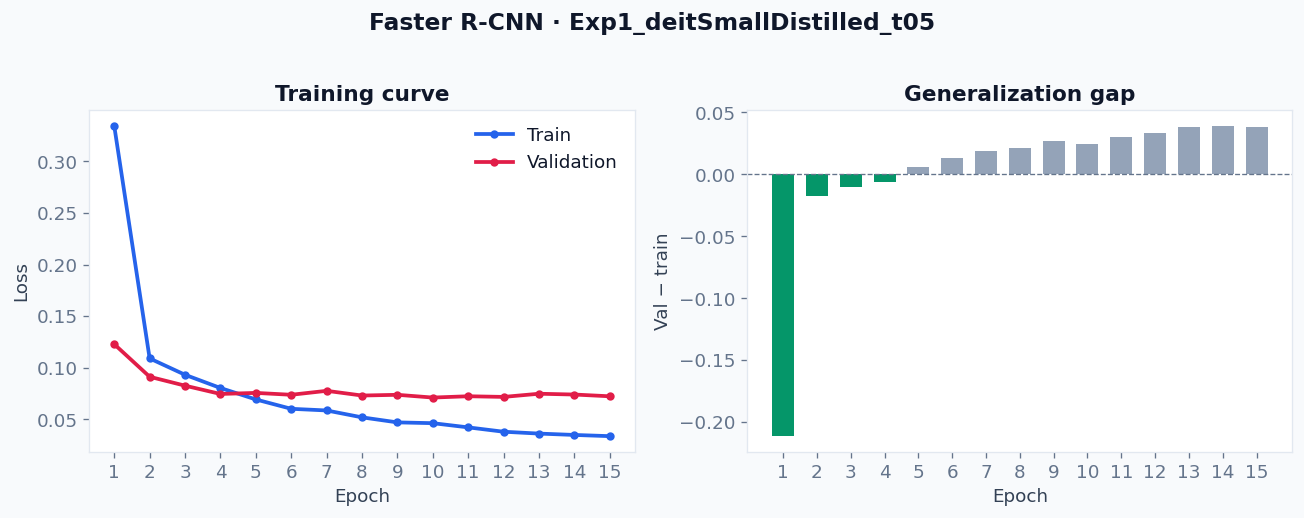

  Saved plot       /kaggle/working/results/rcnn_Exp1_deitSmallDistilled_t05.png

──────────────────────────────────────────────────────
  Test detection metrics
──────────────────────────────────────────────────────
  Experiment       Exp1_deitSmallDistilled_t05
  Confidence       0.50
  Precision        89.3%
  Recall           91.8%
  F1               90.5%
  mIoU             86.7%
──────────────────────────────────────────────────────


  Results log      /kaggle/working/results/results.csv
──────────────────────────────────────────────────────


In [4]:
class EarlyStopping:
    def __init__(self, patience=5, mode="min"):
        self.patience, self.mode = patience, mode
        self.counter, self.best, self.stop = 0, None, False
    def __call__(self, val):
        if self.best is None:
            self.best = val
            return
        improved = val < self.best - 0.001 if self.mode == "min" else val > self.best + 0.001
        if improved:
            self.best, self.counter = val, 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.stop = True

class FasterRCNNTrainer:
    def __init__(self, model, device, lr=0.005, patience=5):
        self.model = model
        self.device = device
        self.save_path = os.path.join(save_dir, "rcnn_best.pth")
        self.history = {"train_loss": [], "val_loss": []}
        self.best_val = float("inf")
        self.optimizer = optim.SGD(
            [p for p in model.parameters() if p.requires_grad],
            lr=lr, momentum=0.9, weight_decay=0.0005)
        self.scheduler = optim.lr_scheduler.CosineAnnealingLR(
            self.optimizer, T_max=epochs_rcnn, eta_min=1e-6)
        self.es = EarlyStopping(patience=patience)

    def _epoch(self, loader, train=True):
        total, n = 0.0, 0
        with torch.set_grad_enabled(train):
            self.model.train()
            for imgs, tgts in loader:
                imgs = [i.to(self.device) for i in imgs]
                tgts = [{k: v.to(self.device) for k, v in t.items()} for t in tgts]
                out = self.model(imgs, tgts)
                if not isinstance(out, dict):
                    raise RuntimeError("Expected loss dict; got " + type(out).__name__)
                loss = sum(out.values())
                if train:
                    self.optimizer.zero_grad()
                    loss.backward()
                    torch.nn.utils.clip_grad_norm_(self.model.parameters(), 1.0)
                    self.optimizer.step()
                total += loss.item()
                n += 1
        return total / n if n else 0.0

    def fit(self, train_loader, valid_loader, epochs):
        _rule("Training")
        print("       train      val")
        for epoch in range(epochs):
            tr = self._epoch(train_loader, True)
            vl = self._epoch(valid_loader, False)
            self.scheduler.step()
            self.history["train_loss"].append(tr)
            self.history["val_loss"].append(vl)
            improved = vl < self.best_val
            if improved:
                self.best_val = vl
                torch.save(self.model.state_dict(), self.save_path)
            self.es(vl)
            print_epoch(epoch + 1, epochs, tr, vl, best=improved, stopped=self.es.stop)
            if self.es.stop:
                break

    def evaluate(self, test_loader, conf_thresh=0.5, iou_thresh=0.5):
        self.model.load_state_dict(torch.load(self.save_path, map_location=self.device))
        self.model.eval()
        tp = fp = fn = 0
        iou_list = []
        def iou_fn(b1, b2):
            x1, y1 = max(b1[0], b2[0]), max(b1[1], b2[1])
            x2, y2 = min(b1[2], b2[2]), min(b1[3], b2[3])
            inter = max(0, x2 - x1) * max(0, y2 - y1)
            union = (b1[2]-b1[0])*(b1[3]-b1[1]) + (b2[2]-b2[0])*(b2[3]-b2[1]) - inter
            return inter / union if union > 0 else 0
        with torch.no_grad():
            for imgs, tgts in test_loader:
                imgs = [i.to(self.device) for i in imgs]
                preds = self.model(imgs)
                for pred, tgt in zip(preds, tgts):
                    gt = tgt["boxes"].cpu().numpy()
                    pb = pred["boxes"].cpu().numpy()
                    ps = pred["scores"].cpu().numpy()
                    pb = pb[ps >= conf_thresh]
                    matched = set()
                    for box in pb:
                        best_i, best_j = 0, -1
                        for j, gb in enumerate(gt):
                            if j in matched:
                                continue
                            v = iou_fn(box, gb)
                            if v > best_i:
                                best_i, best_j = v, j
                        if best_i >= iou_thresh:
                            tp += 1
                            matched.add(best_j)
                            iou_list.append(best_i)
                        else:
                            fp += 1
                    fn += len(gt) - len(matched)
        prec = tp / (tp + fp) if (tp + fp) else 0
        rec = tp / (tp + fn) if (tp + fn) else 0
        f1 = 2 * prec * rec / (prec + rec) if (prec + rec) else 0
        miou = float(np.mean(iou_list)) if iou_list else 0
        self.last_metrics = dict(precision=prec, recall=rec, f1=f1, miou=miou)
        return prec, rec, f1, miou

    def plot(self, experiment_name):
        apply_plot_style()
        epochs_run = len(self.history["train_loss"])
        fig, axes = plt.subplots(1, 2, figsize=(11, 4.2), dpi=120)
        fig.patch.set_facecolor("#f8fafc")
        x = np.arange(1, epochs_run + 1)
        axes[0].plot(x, self.history["train_loss"], color=PALETTE["train"], label="Train", marker="o", markersize=4)
        axes[0].plot(x, self.history["val_loss"], color=PALETTE["val"], label="Validation", marker="o", markersize=4)
        axes[0].set_xlabel("Epoch")
        axes[0].set_ylabel("Loss")
        axes[0].set_title("Training curve")
        axes[0].legend(loc="upper right")
        axes[0].set_xticks(x)
        gap = [v - t for v, t in zip(self.history["val_loss"], self.history["train_loss"])]
        colors = [PALETTE["gap"] if g >= 0 else PALETTE["best"] for g in gap]
        axes[1].bar(x, gap, color=colors, width=0.65, edgecolor="none")
        axes[1].axhline(0, color="#64748b", linewidth=0.8, linestyle="--")
        axes[1].set_xlabel("Epoch")
        axes[1].set_ylabel("Val − train")
        axes[1].set_title("Generalization gap")
        axes[1].set_xticks(x)
        fig.suptitle("Faster R-CNN · " + experiment_name, fontsize=14, fontweight="600", y=1.02)
        fig.tight_layout()
        out_path = os.path.join(save_dir, "rcnn_" + experiment_name + ".png")
        fig.savefig(out_path, dpi=150, bbox_inches="tight", facecolor=fig.get_facecolor())
        plt.show()
        print_kv("Saved plot", out_path)

rcnn_trainer = FasterRCNNTrainer(rcnn_model, DEVICE, lr=lr_rcnn, patience=PATIENCE)
rcnn_trainer.fit(train_det_loader, valid_det_loader, epochs_rcnn)
show_training_summary(rcnn_trainer, epochs_rcnn, Experiment_Name)
rcnn_trainer.plot(Experiment_Name)
rp, rr, rf, riou = rcnn_trainer.evaluate(test_det_loader, Confidence_Threshold, 0.5)
show_metrics_card(rp, rr, rf, riou, Confidence_Threshold, Experiment_Name)
config["rcnn_save_path"] = rcnn_trainer.save_path
with open("/kaggle/working/config.json", "w") as f:
    json.dump(config, f, indent=2)
log_result(Experiment_Name, "FasterRCNN-R50-FPN-V2", rp*100, rp*100, rr*100, rf*100,
           Confidence_Threshold, "ResNet50-FPN-V2", dataset_version,
           "mIoU=" + str(round(riou*100, 2)))
_rule()